## CRS LIST

In [2]:
import pyproj
from pyproj import CRS
import pandas as pd
import json
import re

In [3]:
pyproj.get_authorities() # type: ignore

['EPSG', 'ESRI', 'IAU_2015', 'IGNF', 'NKG', 'NRCAN', 'OGC', 'PROJ']

In [4]:
epsg_codes = pyproj.get_codes('EPSG', 'CRS') # type: ignore
# 创建包含坐标系信息的DataFrame
data = []
for code in epsg_codes:
    crs = CRS.from_epsg(code)
    data.append({
        'EPSG': code,
        'Name': crs.name,
        'Type': 'Geographic' if crs.is_geographic else 'Projected',
        'WKT': crs.to_wkt(),
        'Auth': crs.to_authority()[0]
    })

df = pd.DataFrame(data)
df

,EPSG,Name,Type,WKT,Auth
0,10150,MSL UK & Ireland VORF08 depth,Projected,"VERTCRS[""MSL UK & Ireland VORF08 depth"",VDATUM...",EPSG
1,10151,CD UK & Ireland VORF08 depth,Projected,"VERTCRS[""CD UK & Ireland VORF08 depth"",VDATUM[...",EPSG
2,10156,ETRS89 + MSL UK & Ireland VORF08 depth,Geographic,"COMPOUNDCRS[""ETRS89 + MSL UK & Ireland VORF08 ...",EPSG
3,10157,ETRS89 + CD UK & Ireland VORF08 depth,Geographic,"COMPOUNDCRS[""ETRS89 + CD UK & Ireland VORF08 d...",EPSG
4,10158,S34J-IRF,Geographic,"GEOGCRS[""S34J-IRF"",DATUM[""System 34 Jylland In...",EPSG
...,...,...,...,...,...
7008,9977,FNL22 Grid,Projected,"PROJCRS[""FNL22 Grid"",BASEGEOGCRS[""FNL22-IRF"",D...",EPSG
7009,9978,FNL22 Grid + ODN height,Projected,"COMPOUNDCRS[""FNL22 Grid + ODN height"",PROJCRS[...",EPSG
7010,9988,ITRF2020,Projected,"GEODCRS[""ITRF2020"",DYNAMIC[FRAMEEPOCH[2015]],D...",EPSG
7011,9989,ITRF2020,Geographic,"GEOGCRS[""ITRF2020"",DYNAMIC[FRAMEEPOCH[2015]],D...",EPSG


In [5]:
df_projected = df[df['Type'] == 'Projected']
df_projected.head()

,EPSG,Name,Type,WKT,Auth
0,10150,MSL UK & Ireland VORF08 depth,Projected,"VERTCRS[""MSL UK & Ireland VORF08 depth"",VDATUM...",EPSG
1,10151,CD UK & Ireland VORF08 depth,Projected,"VERTCRS[""CD UK & Ireland VORF08 depth"",VDATUM[...",EPSG
5,10160,S34J reconstruction east-orientated,Projected,"PROJCRS[""S34J reconstruction east-orientated"",...",EPSG
6,10162,JGD2011 / Japan Plane Rectangular CS I + JGD20...,Projected,"COMPOUNDCRS[""JGD2011 / Japan Plane Rectangular...",EPSG
7,10163,JGD2011 / Japan Plane Rectangular CS II + JGD2...,Projected,"COMPOUNDCRS[""JGD2011 / Japan Plane Rectangular...",EPSG


In [6]:
df_cgcs = df[df['Name'].str.contains('CGCS')].reset_index(drop=True)
df_cgcs

,EPSG,Name,Type,WKT,Auth
0,4491,CGCS2000 / Gauss-Kruger zone 13,Projected,"PROJCRS[""CGCS2000 / Gauss-Kruger zone 13"",BASE...",EPSG
1,4492,CGCS2000 / Gauss-Kruger zone 14,Projected,"PROJCRS[""CGCS2000 / Gauss-Kruger zone 14"",BASE...",EPSG
2,4493,CGCS2000 / Gauss-Kruger zone 15,Projected,"PROJCRS[""CGCS2000 / Gauss-Kruger zone 15"",BASE...",EPSG
3,4494,CGCS2000 / Gauss-Kruger zone 16,Projected,"PROJCRS[""CGCS2000 / Gauss-Kruger zone 16"",BASE...",EPSG
4,4495,CGCS2000 / Gauss-Kruger zone 17,Projected,"PROJCRS[""CGCS2000 / Gauss-Kruger zone 17"",BASE...",EPSG
...,...,...,...,...,...
59,4550,CGCS2000 / 3-degree Gauss-Kruger CM 123E,Projected,"PROJCRS[""CGCS2000 / 3-degree Gauss-Kruger CM 1...",EPSG
60,4551,CGCS2000 / 3-degree Gauss-Kruger CM 126E,Projected,"PROJCRS[""CGCS2000 / 3-degree Gauss-Kruger CM 1...",EPSG
61,4552,CGCS2000 / 3-degree Gauss-Kruger CM 129E,Projected,"PROJCRS[""CGCS2000 / 3-degree Gauss-Kruger CM 1...",EPSG
62,4553,CGCS2000 / 3-degree Gauss-Kruger CM 132E,Projected,"PROJCRS[""CGCS2000 / 3-degree Gauss-Kruger CM 1...",EPSG


In [7]:
cgcs_117_wkt = df_cgcs[df_cgcs['Name'].str.contains('3-degree Gauss-Kruger CM 117E')]
cgcs_117_wkt

,EPSG,Name,Type,WKT,Auth
57,4548,CGCS2000 / 3-degree Gauss-Kruger CM 117E,Projected,"PROJCRS[""CGCS2000 / 3-degree Gauss-Kruger CM 1...",EPSG


In [8]:
cgcs_120_wkt = df_cgcs[df_cgcs['Name'].str.contains('3-degree Gauss-Kruger CM 120E')]
cgcs_120_wkt

,EPSG,Name,Type,WKT,Auth
58,4549,CGCS2000 / 3-degree Gauss-Kruger CM 120E,Projected,"PROJCRS[""CGCS2000 / 3-degree Gauss-Kruger CM 1...",EPSG


In [9]:
CRS.from_epsg(4548).to_json_dict()

{'$schema': 'https://proj.org/schemas/v0.7/projjson.schema.json',
 'type': 'ProjectedCRS',
 'name': 'CGCS2000 / 3-degree Gauss-Kruger CM 117E',
 'base_crs': {'name': 'China Geodetic Coordinate System 2000',
  'datum': {'type': 'GeodeticReferenceFrame',
   'name': 'China 2000',
   'ellipsoid': {'name': 'CGCS2000',
    'semi_major_axis': 6378137,
    'inverse_flattening': 298.257222101}},
  'coordinate_system': {'subtype': 'ellipsoidal',
   'axis': [{'name': 'Geodetic latitude',
     'abbreviation': 'Lat',
     'direction': 'north',
     'unit': 'degree'},
    {'name': 'Geodetic longitude',
     'abbreviation': 'Lon',
     'direction': 'east',
     'unit': 'degree'}]},
  'id': {'authority': 'EPSG', 'code': 4490}},
 'conversion': {'name': 'Gauss-Kruger CM 117E',
  'method': {'name': 'Transverse Mercator',
   'id': {'authority': 'EPSG', 'code': 9807}},
  'parameters': [{'name': 'Latitude of natural origin',
    'value': 0,
    'unit': 'degree',
    'id': {'authority': 'EPSG', 'code': 8801}

In [10]:
# 保存为JSON文件
with open('./output/CGCS2000_3-degree Gauss-Kruger CM 117E.json', 'w', encoding='utf-8') as f:
    json.dump(CRS.from_epsg(4548).to_json_dict(), f, indent=4, ensure_ascii=False)

# 保存为JSON文件
with open('./output/CGCS2000_3-degree Gauss-Kruger CM 120E.json', 'w', encoding='utf-8') as f:
    json.dump(CRS.from_epsg(4549).to_json_dict(), f, indent=4, ensure_ascii=False)

In [11]:
import numpy as np

bbox1 = {
    "south_latitude": 24.43,
    "west_longitude": 118.5,
    "north_latitude": 53.33,
    "east_longitude": 121.5,
}

bbox2 = {
    "south_latitude": 22.6,
    "west_longitude": 115.5,
    "north_latitude": 49.88,
    "east_longitude": 118.5,
}

# 计算中间值
mid_bbox = {
    "south_latitude": round((bbox1["south_latitude"] + bbox2["south_latitude"]) / 2, 4),
    "west_longitude": round((bbox1["west_longitude"] + bbox2["west_longitude"]) / 2, 4),    
    "north_latitude": round((bbox1["north_latitude"] + bbox2["north_latitude"]) / 2, 4),
    "east_longitude": round((bbox1["east_longitude"] + bbox2["east_longitude"]) / 2, 4),
}

mid_bbox

{'south_latitude': 23.515,
 'west_longitude': 117.0,
 'north_latitude': 51.605,
 'east_longitude': 120.0}

In [12]:
area1 = "China - onshore between 118°30'E and 121°30'E."
area2 = "China - onshore between 115°30'E and 118°30'E."

area = "China - onshore between 117E and 120E."

### 自定义坐标系

In [13]:
with open('./output/CGCS2000_3-degree Gauss-Kruger CM 1185E.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# 打印数据
data

{'$schema': 'https://proj.org/schemas/v0.7/projjson.schema.json',
 'type': 'ProjectedCRS',
 'name': 'CGCS2000 / 3-degree Gauss-Kruger CM 118.5E',
 'base_crs': {'name': 'China Geodetic Coordinate System 2000',
  'datum': {'type': 'GeodeticReferenceFrame',
   'name': 'China 2000',
   'ellipsoid': {'name': 'CGCS2000',
    'semi_major_axis': 6378137,
    'inverse_flattening': 298.257222101}},
  'coordinate_system': {'subtype': 'ellipsoidal',
   'axis': [{'name': 'Geodetic latitude',
     'abbreviation': 'Lat',
     'direction': 'north',
     'unit': 'degree'},
    {'name': 'Geodetic longitude',
     'abbreviation': 'Lon',
     'direction': 'east',
     'unit': 'degree'}]},
  'id': {'authority': 'EPSG', 'code': 4490}},
 'conversion': {'name': 'Gauss-Kruger CM 118.5E',
  'method': {'name': 'Transverse Mercator'},
  'parameters': [{'name': 'Latitude of natural origin',
    'value': 0,
    'unit': 'degree',
    'id': {'authority': 'EPSG', 'code': 8801}},
   {'name': 'Longitude of natural origi

In [14]:
crs_1185 = CRS.from_json_dict(data)
crs_1185

<Projected CRS: {"$schema": "https://proj.org/schemas/v0.7/projjso ...>
Name: CGCS2000 / 3-degree Gauss-Kruger CM 118.5E
Axis Info [cartesian]:
- X[north]: Northing (metre)
- Y[east]: Easting (metre)
Area of Use:
- name: China - onshore between 117E and 120E.
- bounds: (117.0, 23.515, 120.0, 51.605)
Coordinate Operation:
- name: Gauss-Kruger CM 118.5E
- method: Transverse Mercator
Datum: China 2000
- Ellipsoid: CGCS2000
- Prime Meridian: Greenwich

## 坐标系统转换

In [15]:
from pyproj import Transformer, CRS


def pnt_cgcs2000_to_1185(lat, lon):
    # 创建转换器
    transformer = Transformer.from_crs("EPSG:4490", crs_1185)
    return transformer.transform(lat, lon)

def pnt_1185_to_cgcs2000(lat, lon):
    # 创建转换器
    transformer = Transformer.from_crs("EPSG:4490", crs_1185)
    return transformer.transform(lat, lon, direction="inverse")


In [16]:
pnt_cgcs2000_to_1185(24.5213,118.3826)

(2713033.9450932853, 488102.9484465222)

In [17]:
transformer = Transformer.from_crs("EPSG:4490", "EPSG:4549")
transformer.transform(24.5213,118.3826)

(2713989.2815725794, 336082.03249976924)

In [18]:
transformer = Transformer.from_crs("EPSG:4490", "EPSG:4548")
transformer.transform(24.5213,118.3826)

(2713730.6277515944, 640118.4813193738)

In [19]:
import pandas as pd

df = pd.read_csv(r'E:\help\20250812-mao\经纬度.csv')
df

,lng,lat
0,118.3635,24.5513
1,118.3555,24.5356
2,118.3550,24.5359
3,118.5920,24.8858
4,118.3950,24.5516
...,...,...
193,118.3448,24.5550
194,118.3447,24.5550
195,118.3431,24.5610
196,118.3431,24.5610


In [20]:
from shapely import Point   

df['geometry'] = df.apply(lambda x: Point(x['lng'], x['lat']), axis=1) # type: ignore
df

,lng,lat,geometry
0,118.3635,24.5513,POINT (118.3635 24.5513)
1,118.3555,24.5356,POINT (118.3555 24.5356)
2,118.3550,24.5359,POINT (118.355 24.5359)
3,118.5920,24.8858,POINT (118.592 24.8858)
4,118.3950,24.5516,POINT (118.395 24.5516)
...,...,...,...
193,118.3448,24.5550,POINT (118.3448 24.555)
194,118.3447,24.5550,POINT (118.3447 24.555)
195,118.3431,24.5610,POINT (118.3431 24.561)
196,118.3431,24.5610,POINT (118.3431 24.561)


In [21]:
df.describe()

,lng,lat
count,198.000000,198.000000
mean,118.376315,24.553801
std,0.042299,0.075970
min,118.292100,24.253700
25%,118.351100,24.525700
50%,118.375100,24.543600
75%,118.389975,24.561450
max,118.605500,24.967110


In [22]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(df, geometry='geometry')
gdf['id'] = gdf.index
gdf.set_crs('EPSG:4326', inplace=True)
gdf

,lng,lat,geometry,id
0,118.3635,24.5513,POINT (118.3635 24.5513),0
1,118.3555,24.5356,POINT (118.3555 24.5356),1
2,118.3550,24.5359,POINT (118.355 24.5359),2
3,118.5920,24.8858,POINT (118.592 24.8858),3
4,118.3950,24.5516,POINT (118.395 24.5516),4
...,...,...,...,...
193,118.3448,24.5550,POINT (118.3448 24.555),193
194,118.3447,24.5550,POINT (118.3447 24.555),194
195,118.3431,24.5610,POINT (118.3431 24.561),195
196,118.3431,24.5610,POINT (118.3431 24.561),196


c:\Envs\miniforge3\envs\data\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24102 (\N{CJK UNIFIED IDEOGRAPH-5E26}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Envs\miniforge3\envs\data\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23646 (\N{CJK UNIFIED IDEOGRAPH-5C5E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Envs\miniforge3\envs\data\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Envs\miniforge3\envs\data\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Envs\miniforge3\envs\data\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing fro

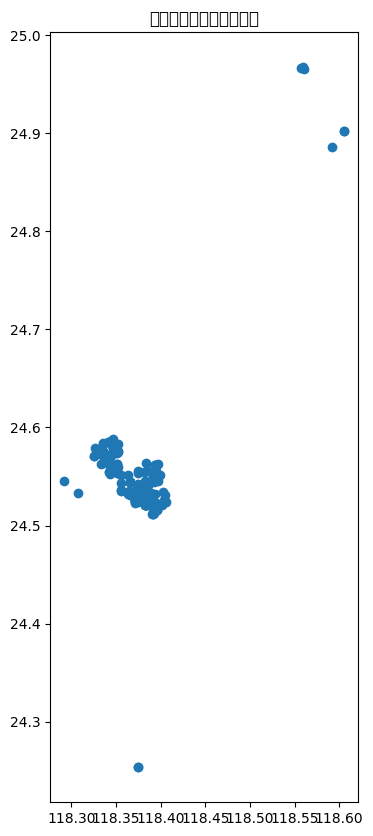

In [23]:
import matplotlib.pyplot as plt

# 带属性的可视化
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, legend=True)
plt.title('带属性的地理数据可视化')
plt.show()

In [24]:
# 交互式可视化（需要安装folium）
import folium

m = gdf.explore(
    # column="属性列名",  # 指定着色列
    tooltip="id",  # 悬停提示
    popup=True,        # 点击弹出
    tiles="CartoDB positron",  # 底图样式
    cmap="viridis",    # 颜色方案
    style_kwds={"opacity": 0.5}  # 透明度
)
m.save("map.html")  # 保存为HTML文件